# Centralized Baseline

> Implementation of the centralized models that run on the server side, establishing the performance ceiling for the federated experiments.

---

## Motivation

For health-related applications, high interpretability models are generally preferred, but in a FL setup those models do not make much sense, as we work with iterations and gradient descent, which highly suits NN models. This project is not about that, but rather the FL technicality. For the centralized baseline, two models have been trained: **XGBoost** and a **Neural Network (MLP)**.

---

## Dataset

The **Diabetes 130-US Hospitals for Years 1999–2008** dataset was chosen for this project, as it can be understood that hospitals cannot share data between themselves — only sharing finalized models — so it makes sense in a realistic federated scenario.

| Property | Details |
|---|---|
| Time span | 1999–2008 |
| Hospitals | 130 US hospitals |
| Samples | ~101,766 patient encounters |
| Task | Predict 30-day hospital readmission |

This dataset is challenging: some data preparation must be done, and state-of-the-art models achieve around **0.667 AUC-ROC**. Its relatively small size also reflects what we encounter in everyday hospital settings, making it a realistic and useful reference.

---

## Results Summary

| Model | AUC-ROC | Notes |
|---|---|---|
| XGBoost | **0.665** | Near SOTA, incompatible with FL |
| MLP | **0.663** | FL-compatible neural baseline |

Both models closely match the published benchmark, confirming they are solid baselines for the federated experiments.

---

In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from IPython.display import display, Markdown
import zipfile
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, roc_auc_score
)
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



## Data Preprocessing

Preprocessing starts by replacing all missing values (encoded as `'?'`) with `NaN`. Columns with over 40% missing data are dropped (e.g. `weight`). For the remaining affected columns — `race`, `diag_1`, `diag_2`, `diag_3` — missing values are filled with `'Unknown'`, affecting at most 3% of the dataset.

The **target variable** is binarized:
- `1` — readmitted within 30 days
- `0` — otherwise

This produces an approximate class imbalance of **1:9**, discussed below.

Categorical features are mapped to clinically meaningful groups — ICD-9 diagnosis codes to eight disease categories, admission and discharge fields to broad types — and then **one-hot encoded**, which is why the working dataset has more columns than the original.


In [82]:
COLS_TO_DROP = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code', 
                'encounter_id']

DECEASED_IDS = [11, 19, 20, 21]

ADMISSION_TYPE_MAP = {
    1: 'emergency', 2: 'urgent',   3: 'elective',
    4: 'newborn',   5: 'unknown',  6: 'unknown',
    7: 'emergency', 8: 'unknown'
}

ADMISSION_SOURCE_MAP = {
    1: 'referral',  2: 'referral',  3: 'referral',
    4: 'transfer',  5: 'transfer',  6: 'transfer',
    10: 'transfer', 22: 'transfer', 25: 'transfer', 
    26: 'transfer', 18: 'transfer',                  
    7: 'emergency',
    8: 'other',
    9: 'unknown',  15: 'unknown', 17: 'unknown',
    20: 'unknown', 21: 'unknown',
    11: 'newborn', 12: 'newborn', 13: 'newborn',
    14: 'newborn', 23: 'newborn', 24: 'newborn',
    19: 'other',                                     
}

AGE_MAP = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}

MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

MED_MAP = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}



In [83]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw CSV and replace ? with NaN."""
    df = pd.read_csv(path)
    df.replace('?', np.nan, inplace=True)
    return df


def drop_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop high-missing and ID columns."""
    return df.drop(columns=COLS_TO_DROP)


def remove_deceased(df: pd.DataFrame) -> pd.DataFrame:
    """Remove patients who died — they cannot be readmitted."""
    return df[~df['discharge_disposition_id'].isin(DECEASED_IDS)].copy()


def create_target(df: pd.DataFrame) -> pd.DataFrame:
    """Create binary target: 1 if readmitted within 30 days, 0 otherwise."""
    df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
    df.drop(columns=['readmitted'], inplace=True)
    return df


def group_discharge(x):
    if x in [11, 19, 20, 21]:          return 'expired'
    elif x in [1, 6, 8]:               return 'home'
    elif x in [2, 3, 4, 5, 10, 15,
               22, 23, 24, 27, 28,
               29, 30]:                return 'transfer'
    elif x in [13, 14]:                return 'hospice'
    elif x == 7:                       return 'ama'
    elif x in [9, 12]:                 return 'inpatient'  # still admitted
    elif x in [18, 25, 26]:            return 'unknown'
    else:                              return 'other'


def group_icd9(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'): return 'other'
        c = float(code)
        if   390 <= c <= 459 or c == 785: return 'circulatory'
        elif 460 <= c <= 519 or c == 786: return 'respiratory'
        elif 520 <= c <= 579 or c == 787: return 'digestive'
        elif 250 <= c <= 250.99:          return 'diabetes'
        elif 800 <= c <= 999:             return 'injury'
        elif 710 <= c <= 739:             return 'musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'genitourinary'
        elif 140 <= c <= 239:             return 'neoplasms'
        else:                             return 'other'
    except:
        return 'other'


def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all feature encoding and grouping."""
    # Ordinal
    df['age'] = df['age'].map(AGE_MAP)

    # Clinical groupings
    df['admission_type_id'] = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('unknown')
    df['admission_source_id']     = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
    df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)

    # ICD-9 diagnosis codes
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(group_icd9)

    # Medication columns
    for col in MED_COLS:
        if col in df.columns:
            df[col] = df[col].map(MED_MAP)

    df['change']      = (df['change'] == 'Ch').astype(int)
    df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

    # One-hot encode categoricals
    df = pd.get_dummies(df, columns=[
        'diag_1', 'diag_2', 'diag_3',
        'admission_type_id', 'admission_source_id',
        'discharge_disposition_id', 'race', 'gender'
    ])

    return df


def prepare_data(path: str, verbose: bool = True) -> tuple:
    """
    Full pipeline from raw CSV to X, y arrays.
    Returns X, y as numpy arrays.
    """
    df = load_data(path)
    df = drop_columns(df)
    df = remove_deceased(df)
    df = create_target(df)
    # Race only has 2000 missing out of 100k, so we can impute 'Unknown' instead of dropping rows
    df['race'] = df['race'].fillna('Unknown')
    # We still have some missing values in diag_1/2/3 and admission_source_id, but these are more complex to impute, so we'll just drop those rows      
    df.dropna(inplace=True)
    df = encode_features(df)

    if verbose:
        print(f"Dataset shape: {df.shape}")
        print(f"Class distribution:\n{df['readmitted_binary'].value_counts()}")

    groups = df['patient_nbr'].values
    X = df.drop(columns=['readmitted_binary', 'patient_nbr']).values
    y = df['readmitted_binary'].values

    return X, y, groups

X, y, groups = prepare_data('diabetes_data/diabetic_data.csv')


Dataset shape: (98594, 90)
Class distribution:
readmitted_binary
0    87344
1    11250
Name: count, dtype: int64


## Train / Validation / Test Split

To prevent **data leakage** — the same patient appearing in both training and test sets — the split is performed at the **patient level**, using `patient_nbr` as the grouping key, which is then dropped.

| Split | Size |
|---|---|
| Train | 68% |
| Validation | 12% |
| Test | 20% |

In [84]:
# Patient-level train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_temp, X_test = X[train_idx], X[test_idx]
y_temp, y_test = y[train_idx], y[test_idx]
groups_temp = groups[train_idx]

# Patient-level train/val split
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx2, val_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
y_train, y_val = y_temp[train_idx2], y_temp[val_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Tensors for val/test (no SMOTE on these)
X_val_t  = torch.tensor(X_val_scaled,  dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_val_t  = torch.tensor(y_val,  dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Train DataLoader (no SMOTE)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=1024, shuffle=True)

Train: (67107, 88), Val: (11827, 88), Test: (19660, 88)


## Class Imbalance

The dataset has a class imbalance of approximately **9:1**. Instead of synthetic oversampling (e.g. SMOTE), which can produce unrealistic samples for one-hot encoded medical data, **class-weighted cross-entropy loss** is used. Weights are computed inversely proportional to class frequencies, penalizing the model more heavily for missed readmissions.


Class Distribution:
0    59446
1     7661
Name: count, dtype: int64

Class Proportions:
0    0.885839
1    0.114161
Name: proportion, dtype: float64


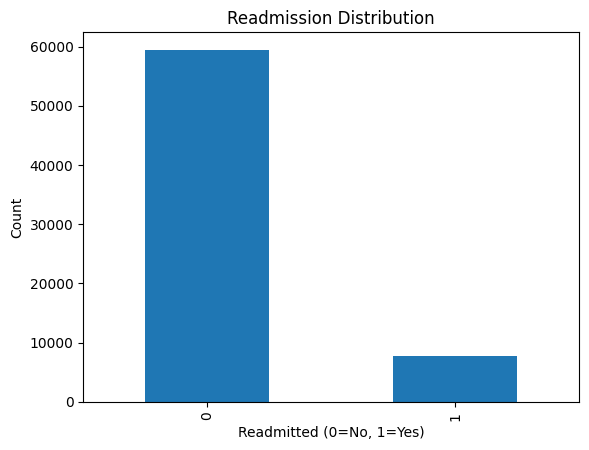

In [85]:
# Check class distribution
print("Class Distribution:")
print(pd.Series(y_train_t).value_counts())
print("\nClass Proportions:")
print(pd.Series(y_train_t).value_counts(normalize=True))

# Visualize

pd.Series(y_train_t).value_counts().plot(kind='bar', title='Readmission Distribution')
plt.xlabel('Readmitted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## XGBoost

A gradient boosted tree ensemble used as the **performance ceiling**. Key design choices:

- `scale_pos_weight` set to the negative-to-positive class ratio to handle imbalance natively
- Early stopping on validation AUC to prevent overfitting

> Important: XGBoost is incompatible with FL frameworks — it cannot be federated meaningfully. It serves purely as an upper-bound reference.


In [86]:

# Class imbalance ratio (~9:1)
scale = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,   # handles class imbalance natively
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=25 ,
    device='cuda'             # remove if no GPU
)

model_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

# Evaluate
y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = model_xgb.predict(X_test_scaled) 

print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

[0]	validation_0-auc:0.62954
[50]	validation_0-auc:0.64226
[79]	validation_0-auc:0.64058
              precision    recall  f1-score   support

           0       0.93      0.65      0.77     17422
           1       0.18      0.60      0.28      2238

    accuracy                           0.65     19660
   macro avg       0.55      0.63      0.52     19660
weighted avg       0.84      0.65      0.71     19660

AUC-ROC: 0.665


In [87]:
df_temp = pd.read_csv('diabetes_data/diabetic_data.csv')
df_temp.replace('?', np.nan, inplace=True)
df_temp = drop_columns(df_temp)
df_temp = remove_deceased(df_temp)
df_temp = create_target(df_temp)
df_temp.dropna(inplace=True)
df_temp = encode_features(df_temp)
feature_names_list = df_temp.drop(columns=['readmitted_binary', 'patient_nbr']).columns.tolist()

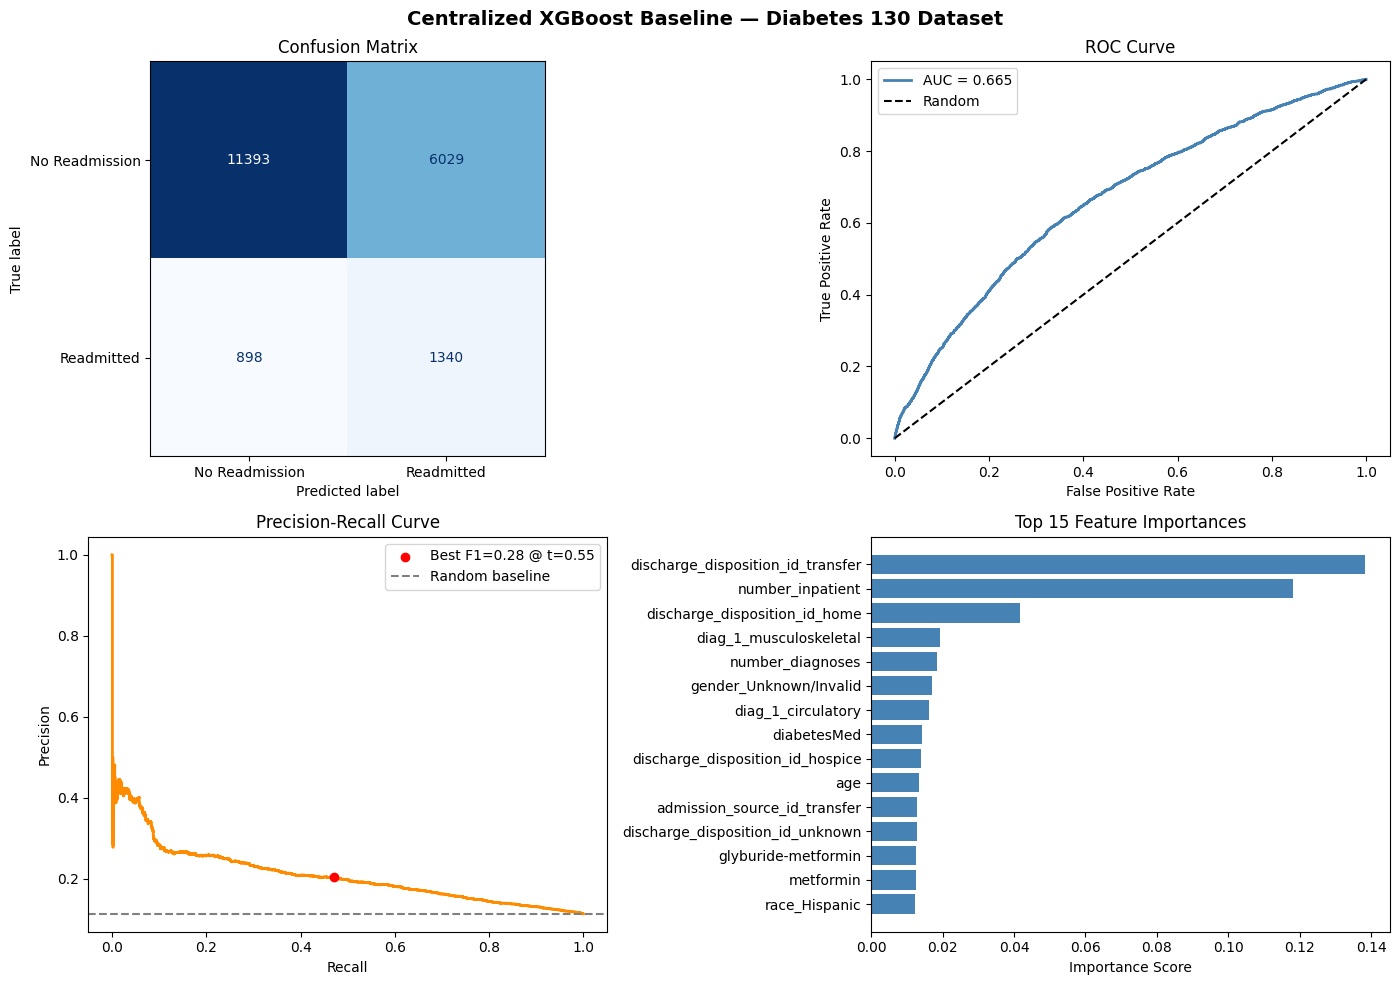

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Centralized XGBoost Baseline — Diabetes 130 Dataset', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Readmission', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

# 3. Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
ax3.plot(recall, precision, color='darkorange', lw=2)
ax3.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best F1={f1_scores[best_idx]:.2f} @ t={thresholds[best_idx]:.2f}')
ax3.axhline(y_test.mean(), color='gray', linestyle='--', label='Random baseline')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend()

# 4. Top 15 Feature Importances
ax4 = axes[1, 1]
importances = model_xgb.feature_importances_
top_idx = np.argsort(importances)[-15:]
feature_names = [feature_names_list[i] for i in top_idx]
ax4.barh(feature_names, importances[top_idx], color='steelblue')
ax4.set_title('Top 15 Feature Importances')
ax4.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('xgboost_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## MLP

A three-layer perceptron serving as the **federated-compatible neural baseline**. Architecture and training details:

- Batch normalization and dropout after each hidden layer
- Adam optimizer, learning rate `0.001`
- Up to 100 epochs, best checkpoint retained by validation loss

> Important: While NNs are not the preferred choice for medical data in practice — where interpretability is critical for clinical trust — the focus of this project is the FL-KD framework rather than clinical deployment.



In [89]:
# Simple MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [90]:
# 1. More aggressive class weights
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Boost the minority class weight even further
# cw[1] *= 1.5  # double the minority weight — experiment with this multiplier
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
input_dim = X_train_scaled.shape[1]  
model = MLP(input_dim=input_dim, hidden_dim=256, output_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights)  # use this in training loop

In [91]:
# Training loop
best_val_loss = float('inf')
best_state = None

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t.to(device))
        val_loss = criterion(val_logits, y_val_t.to(device))  
        val_preds = val_logits.argmax(dim=1).cpu()
        val_acc = (val_preds == y_val_t).float().mean()

    scheduler.step(val_loss.item())  
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

# after loop:
model.load_state_dict(best_state)

Epoch 0 | Val Loss: 0.6605 | Val Acc: 0.646
Epoch 10 | Val Loss: 0.6601 | Val Acc: 0.643
Epoch 20 | Val Loss: 0.6678 | Val Acc: 0.633
Epoch 30 | Val Loss: 0.6713 | Val Acc: 0.638
Epoch 40 | Val Loss: 0.6733 | Val Acc: 0.643
Epoch 50 | Val Loss: 0.6727 | Val Acc: 0.642
Epoch 60 | Val Loss: 0.6724 | Val Acc: 0.644
Epoch 70 | Val Loss: 0.6737 | Val Acc: 0.643
Epoch 80 | Val Loss: 0.6729 | Val Acc: 0.644
Epoch 90 | Val Loss: 0.6733 | Val Acc: 0.643


<All keys matched successfully>

In [92]:
# Eval
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()


print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.63      0.75     17422
           1       0.18      0.62      0.27      2238

    accuracy                           0.63     19660
   macro avg       0.55      0.62      0.51     19660
weighted avg       0.84      0.63      0.70     19660



In [93]:
# Force numeric conversion
X_test_tensor = torch.tensor(X_test_scaled.astype(np.float32))

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor.cuda())
    y_proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f}")

AUC-ROC: 0.663


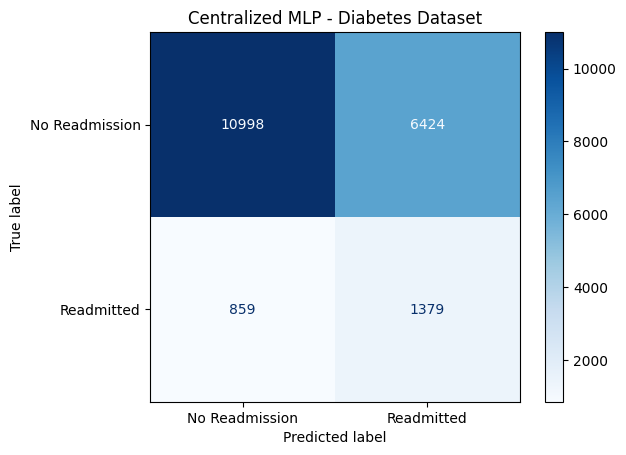

In [94]:
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmission', 'Readmitted'])
disp.plot(cmap='Blues')
plt.title('Centralized MLP - Diabetes Dataset')
plt.show()

Best threshold: 0.553
Best F1: 0.282


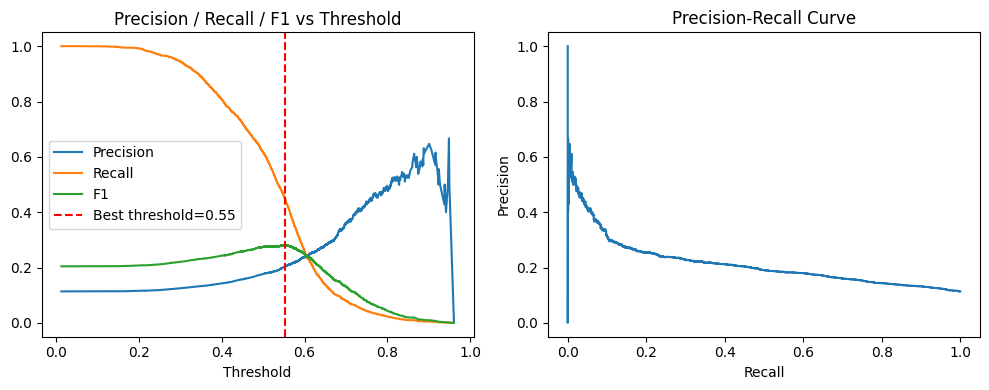

              precision    recall  f1-score   support

           0       0.92      0.78      0.84     17422
           1       0.20      0.45      0.28      2238

    accuracy                           0.74     19660
   macro avg       0.56      0.61      0.56     19660
weighted avg       0.84      0.74      0.78     19660



In [95]:
# Get probabilities (make sure to use scaled data)
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

# Compute precision/recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1: {f1_scores[best_idx]:.3f}")

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision / Recall / F1 vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

# Apply best threshold
preds_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, preds_tuned))

In [96]:
import shap

background = torch.tensor(X_train_scaled[:500], dtype=torch.float32).to(device)
explainer = shap.DeepExplainer(model, background)

X_explain = torch.tensor(X_test_scaled[:500], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_explain)

# Debug shape first
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(500, 88, 2)


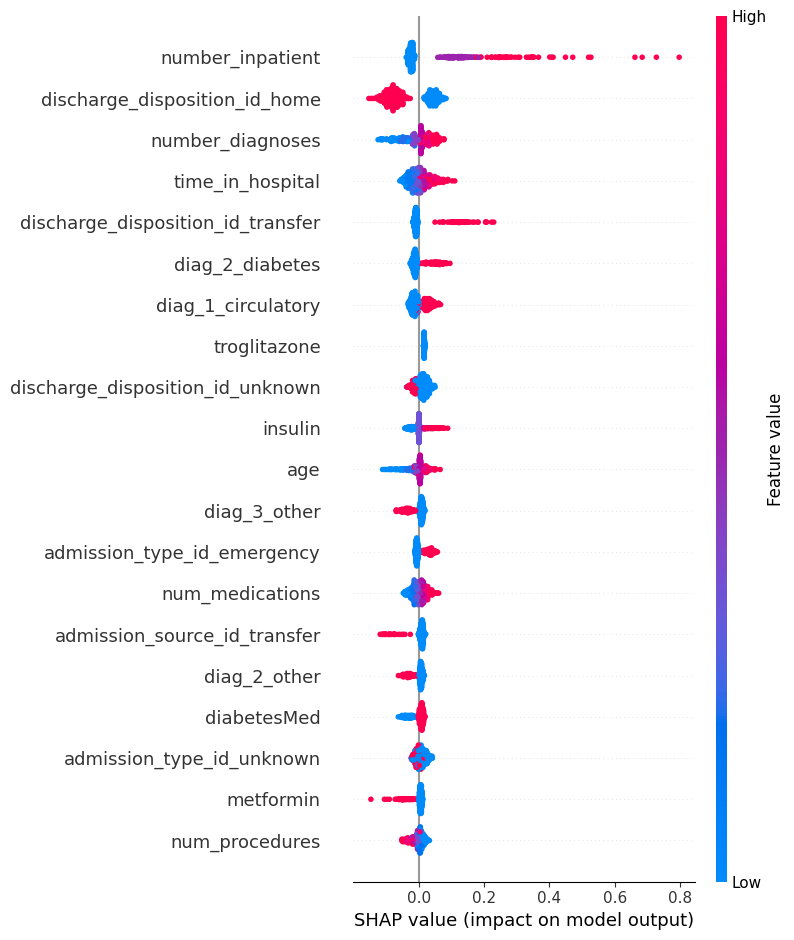

In [97]:
import shap

# SHAP expects numpy, use a background sample for efficiency
background = X_train_scaled[:500]  # small background dataset
explainer = shap.DeepExplainer(model, torch.tensor(background, dtype=torch.float32).to(device))

# Explain test set (use a sample, not all 19k rows)
X_explain = torch.tensor(X_test_scaled[:500], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_explain)

# Plot - shap_values[1] is for class 1 (readmitted)
shap.summary_plot(
    shap_values[:, :, 1],    # class 1
    X_test_scaled[:500],
    feature_names=feature_names_list
)



## Interpretability vs FL Suitability

A natural question arises when designing models for federated healthcare applications: is there a model that is both **highly interpretable** and **well-suited for FL**?

This is an open research problem, but the current landscape can be summarised as follows:

| Model | Interpretability | FL Suitability |
|---|---|---|
| Logistic Regression | ✅ High | ✅ High |
| Decision Tree | ✅ High | ❌ Poor |
| XGBoost | 🟡 Medium (via SHAP) | ❌ Poor |
| MLP | ❌ Low | ✅ High |
| MLP + SHAP | 🟡 Post-hoc | ✅ High |

**Logistic Regression** is the closest model to satisfying both requirements — it is fully interpretable via its coefficients and trains via gradient descent, making it compatible with FedAvg aggregation. However, it is a weak learner for complex tabular data and unlikely to capture the non-linear relationships present in clinical datasets.

**Tree-based models** such as Decision Trees and XGBoost offer strong interpretability, but are fundamentally incompatible with FL. Their sequential, tree-building nature cannot be meaningfully aggregated across clients the way neural network gradients can.

**Neural networks** are the natural fit for FL but are inherently opaque. The practical solution adopted in recent research is to apply **post-hoc interpretability tools** — such as SHAP (SHapley Additive exPlanations) — on top of a trained FL model. SHAP values can be computed locally at each client without sharing patient data, and provide clinicians with feature-level explanations of individual predictions.

> In this project, SHAP is applied to the centralized MLP baseline as a proof of concept, illustrating which features most strongly drive 30-day readmission predictions. This approach could naturally extend to the federated setting, where local SHAP explanations could be computed per client post-aggregation.
